# IDEAM Station Consolidation: Universidad del Valle 2010–2026

**Station:** Universidad del Valle (UNIVALLE)
**Code:** 26055120
**Period:** 2010–2026

## Section 1 — File Inventory

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [2]:
current = Path.cwd()
ideam_dir = None
while current != current.parent:
    potential = current / "shared" / "data" / "raw" / "IDEAM"
    if potential.is_dir():
        ideam_dir = potential
        break
    current = current.parent

if ideam_dir is None:
    raise FileNotFoundError("IDEAM directory not found")

univalle_dir = ideam_dir / "Univalle"
if not univalle_dir.is_dir():
    raise FileNotFoundError(f"Univalle directory not found at {univalle_dir}")

print(f"Found Univalle directory: {univalle_dir}")

Found Univalle directory: /home/boris/PycharmProjects/CaliHeatWaves/shared/data/raw/IDEAM/Univalle


In [3]:
files_expected = [
    "descargaDhime_Univalle_2010_2015.csv",
    "descargaDhime_Univalle_2015_2020.csv",
    "descargaDhime_univalle_2020_2026.csv"
]

files_dict = {}
for fname in files_expected:
    fpath = univalle_dir / fname
    if not fpath.exists():
        raise FileNotFoundError(f"Required file not found: {fpath}")
    files_dict[fname] = fpath

print(f"\n{'='*80}")
print("FILE INVENTORY")
print(f"{'='*80}")
print(f"\n{'Filename':<45} {'Size (KB)':<15} {'Row Count'}")
print("-" * 80)

for fname, fpath in files_dict.items():
    size_kb = os.path.getsize(fpath) / 1024
    with open(fpath) as f:
        row_count = sum(1 for _ in f) - 1
    print(f"{fname:<45} {size_kb:>12.1f} KB  {row_count:>12,d}")

print("\nAll three files located and verified.")


FILE INVENTORY

Filename                                      Size (KB)       Row Count
--------------------------------------------------------------------------------
descargaDhime_Univalle_2010_2015.csv                2693.3 KB        20,924
descargaDhime_Univalle_2015_2020.csv                 228.3 KB         1,773
descargaDhime_univalle_2020_2026.csv                1436.7 KB        11,162

All three files located and verified.


## Section 2 — Load Each File

In [4]:
dfs_raw = {}

for fname, fpath in files_dict.items():
    df = pd.read_csv(fpath, parse_dates=["Fecha"], dtype={"CodigoEstacion": str, "Valor": float})
    dfs_raw[fname] = df
    
    unique_codigos = df["CodigoEstacion"].unique()
    if len(unique_codigos) != 1:
        raise ValueError(f"{fname}: Expected 1 station code, found {len(unique_codigos)}")
    
    unique_variables = df["Variable"].unique()
    if len(unique_variables) != 1:
        raise ValueError(f"{fname}: Expected 1 variable, found {len(unique_variables)}")
    
    unique_units = df["Unidad"].unique()
    if len(unique_units) != 1:
        raise ValueError(f"{fname}: Expected 1 unit, found {len(unique_units)}")

print(f"Loaded {len(dfs_raw)} files, all pass structural checks.")

Loaded 3 files, all pass structural checks.


## Section 3 — Harmonize and Concatenate

In [5]:
dfs_harmonized = {}

for fname, df in dfs_raw.items():
    df_h = df[["Fecha", "Valor", "CodigoEstacion", "NivelAprobacion"]].copy()
    df_h.columns = ["fecha", "valor", "codigo", "aprobacion"]
    df_h["source_file"] = fname
    dfs_harmonized[fname] = df_h

df_all = pd.concat(list(dfs_harmonized.values()), ignore_index=True)
df_all = df_all.sort_values("fecha").reset_index(drop=True)

print(f"{'='*80}")
print("CONCATENATION AND DEDUPLICATION")
print(f"{'='*80}")
print(f"\nTotal rows before deduplication: {len(df_all)}")

duplicates = df_all[df_all.duplicated(subset=["fecha"], keep=False)].sort_values("fecha")
unique_duplicate_fechas = duplicates["fecha"].nunique()

print(f"\nExact duplicate timestamps (same fecha):")
if len(duplicates) > 0:
    print(f"  Unique fecha values duplicated: {unique_duplicate_fechas}")
    print(f"\n  First 10 duplicated timestamps:")
    shown = 0
    for fecha, group in duplicates.groupby("fecha"):
        if shown >= 10:
            break
        sources = group["source_file"].tolist()
        print(f"    {fecha}: sources={sources}")
        shown += 1
else:
    print(f"  None found")

df_all = df_all.drop_duplicates(subset=["fecha"], keep="last").reset_index(drop=True)

print(f"\nTotal rows after deduplication: {len(df_all)}")
print(f"Rows removed: {unique_duplicate_fechas}")

CONCATENATION AND DEDUPLICATION

Total rows before deduplication: 33859



Exact duplicate timestamps (same fecha):
  Unique fecha values duplicated: 1763

  First 10 duplicated timestamps:
    2020-01-01 08:00:00: sources=['descargaDhime_univalle_2020_2026.csv', 'descargaDhime_Univalle_2015_2020.csv']
    2020-01-01 09:00:00: sources=['descargaDhime_Univalle_2015_2020.csv', 'descargaDhime_univalle_2020_2026.csv']
    2020-01-01 10:00:00: sources=['descargaDhime_univalle_2020_2026.csv', 'descargaDhime_Univalle_2015_2020.csv']
    2020-01-01 11:00:00: sources=['descargaDhime_univalle_2020_2026.csv', 'descargaDhime_Univalle_2015_2020.csv']
    2020-01-01 12:00:00: sources=['descargaDhime_univalle_2020_2026.csv', 'descargaDhime_Univalle_2015_2020.csv']
    2020-01-01 13:00:00: sources=['descargaDhime_Univalle_2015_2020.csv', 'descargaDhime_univalle_2020_2026.csv']
    2020-01-01 14:00:00: sources=['descargaDhime_univalle_2020_2026.csv', 'descargaDhime_Univalle_2015_2020.csv']
    2020-01-01 15:00:00: sources=['descargaDhime_univalle_2020_2026.csv', 'descargaDhi

## Section 4 — Coverage Summary

In [6]:
start_time = df_all["fecha"].min()
end_time = df_all["fecha"].max()

print(f"\n{'='*80}")
print("COVERAGE SUMMARY")
print(f"{'='*80}")
print(f"\nStart date: {start_time}")
print(f"End date: {end_time}")

expected_records = (end_time - start_time).total_seconds() / 3600 + 1
actual_records = len(df_all)
missing = expected_records - actual_records
coverage_pct = (actual_records / expected_records) * 100 if expected_records > 0 else 0

print(f"\nExpected hourly records: {expected_records:.0f}")
print(f"Actual records: {actual_records}")
print(f"Missing: {missing:.0f}")
print(f"Coverage: {coverage_pct:.2f}%")


COVERAGE SUMMARY

Start date: 2011-02-25 01:00:00
End date: 2024-12-13 14:00:00

Expected hourly records: 120974
Actual records: 32096
Missing: 88878
Coverage: 26.53%


In [7]:
time_diffs = df_all["fecha"].diff()
max_gaps = time_diffs.nlargest(5)

print(f"\nTop 5 longest gaps:")
for i, (idx, gap) in enumerate(max_gaps.items(), 1):
    if pd.isna(gap):
        continue
    gap_hours = gap.total_seconds() / 3600
    gap_days = gap.days + gap.seconds / 86400
    before = df_all.loc[idx - 1, "fecha"] if idx > 0 else None
    after = df_all.loc[idx, "fecha"]
    print(f"  {i}. {gap_hours:.1f} hours ({gap_days:.1f} days): {before} to {after}")


Top 5 longest gaps:
  1. 43809.0 hours (1825.4 days): 2014-12-31 23:00:00 to 2019-12-31 08:00:00
  2. 18578.0 hours (774.1 days): 2020-04-17 13:00:00 to 2022-05-31 15:00:00
  3. 10370.0 hours (432.1 days): 2023-03-16 14:00:00 to 2024-05-21 16:00:00
  4. 3688.0 hours (153.7 days): 2011-07-31 09:00:00 to 2012-01-01 01:00:00
  5. 3571.0 hours (148.8 days): 2012-10-09 15:00:00 to 2013-03-07 10:00:00


In [8]:
df_all["year"] = df_all["fecha"].dt.year
yearly_counts = df_all.groupby("year").size()

yearly_expected = {}
for year in yearly_counts.index:
    year_data = df_all[df_all["year"] == year]
    year_start = year_data["fecha"].min()
    year_end = year_data["fecha"].max()
    expected = (year_end - year_start).total_seconds() / 3600 + 1
    yearly_expected[year] = expected

yearly_pct = (yearly_counts / pd.Series(yearly_expected)) * 100

print(f"\nCoverage by year:")
for year in sorted(yearly_counts.index):
    print(f"  {year}: {yearly_pct[year]:6.1f}%")


Coverage by year:
  2011:  100.0%
  2012:   37.1%
  2013:   91.9%
  2014:   91.9%
  2019:  100.0%
  2020:   68.5%
  2022:   99.7%
  2023:   94.6%
  2024:   88.3%


## Section 5 — Physical Plausibility

In [9]:
print(f"\n{'='*80}")
print("PHYSICAL PLAUSIBILITY")
print(f"{'='*80}")

valid_temps = df_all["valor"].dropna()

print(f"\nTemperature (degC) statistics:")
print(f"  Min: {valid_temps.min():.2f}")
print(f"  Max: {valid_temps.max():.2f}")
print(f"  Mean: {valid_temps.mean():.2f}")
print(f"  Median: {valid_temps.median():.2f}")
print(f"  Std Dev: {valid_temps.std():.2f}")

cold_count = (valid_temps < 10).sum()
hot_count = (valid_temps > 40).sum()

print(f"\nSuspicious readings:")
print(f"  T < 10 degC: {cold_count}")
print(f"  T > 40 degC: {hot_count}")

print(f"\nTop 5 highest temperatures:")
for idx, (fecha, valor) in enumerate(df_all.nlargest(5, "valor")[["fecha", "valor"]].values, 1):
    print(f"  {idx}. {fecha}: {valor:.2f} degC")

print(f"\nTop 5 lowest temperatures:")
for idx, (fecha, valor) in enumerate(df_all.nsmallest(5, "valor")[["fecha", "valor"]].values, 1):
    print(f"  {idx}. {fecha}: {valor:.2f} degC")


PHYSICAL PLAUSIBILITY

Temperature (degC) statistics:
  Min: 15.80
  Max: 37.80
  Mean: 25.23
  Median: 24.90
  Std Dev: 4.21

Suspicious readings:
  T < 10 degC: 0
  T > 40 degC: 0

Top 5 highest temperatures:
  1. 2022-08-30 11:00:00: 37.80 degC
  2. 2022-08-08 16:00:00: 37.70 degC
  3. 2022-08-30 10:00:00: 37.70 degC
  4. 2022-08-30 17:00:00: 37.70 degC
  5. 2022-08-24 16:00:00: 37.60 degC

Top 5 lowest temperatures:
  1. 2024-08-30 06:00:00: 15.80 degC
  2. 2024-08-30 05:00:00: 15.90 degC
  3. 2011-03-11 06:00:00: 16.20 degC
  4. 2014-08-31 06:00:00: 16.30 degC
  5. 2011-03-11 03:00:00: 16.40 degC


## Section 6 — Diurnal Cycle Sanity Check

In [10]:
df_all["hour"] = df_all["fecha"].dt.hour
hourly_mean = df_all.groupby("hour")["valor"].mean()

print(f"\n{'='*80}")
print("DIURNAL CYCLE SANITY CHECK")
print(f"{'='*80}")

peak_hour = hourly_mean.idxmax()
trough_hour = hourly_mean.idxmin()
amplitude = hourly_mean.max() - hourly_mean.min()

print(f"\nDiurnal cycle statistics:")
print(f"  Peak hour: {peak_hour:02d}h ({hourly_mean.max():.2f} degC)")
print(f"  Trough hour: {trough_hour:02d}h ({hourly_mean.min():.2f} degC)")
print(f"  Amplitude: {amplitude:.2f} degC")

if 14 <= peak_hour <= 16:
    print(f"  Peak hour is ~{peak_hour}h (typical for Andean tropical station)")
else:
    print(f"  Warning: Peak hour is {peak_hour}h (check timezone)")


DIURNAL CYCLE SANITY CHECK

Diurnal cycle statistics:
  Peak hour: 14h (30.87 degC)
  Trough hour: 06h (20.96 degC)
  Amplitude: 9.92 degC
  Peak hour is ~14h (typical for Andean tropical station)


## Section 7 — Time Series Chart

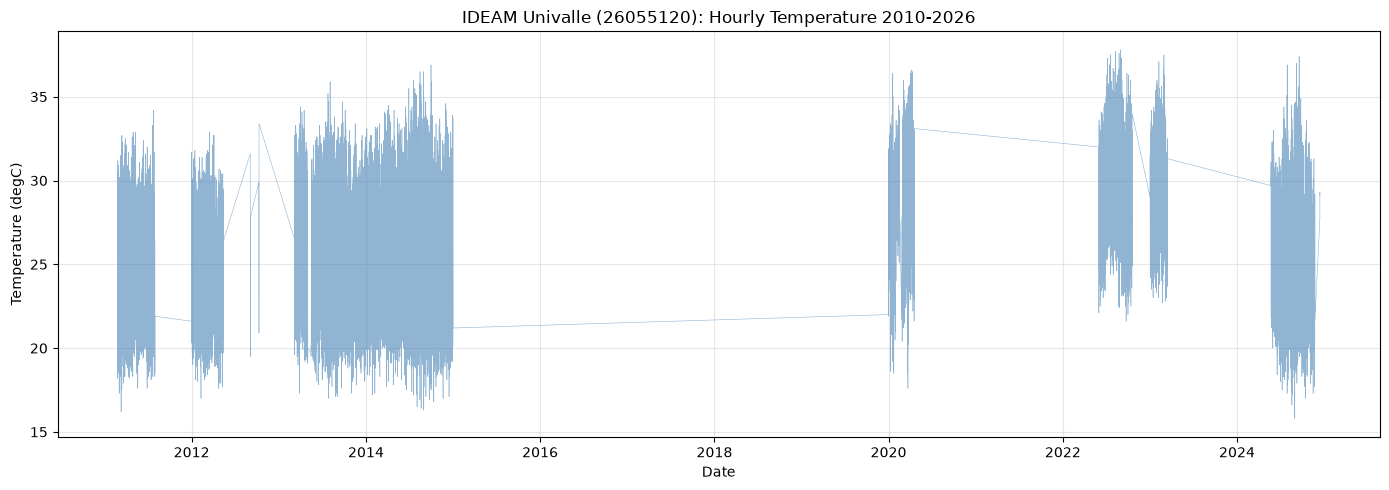

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_all["fecha"], df_all["valor"], linewidth=0.4, color="steelblue", alpha=0.6)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (degC)")
ax.set_title("IDEAM Univalle (26055120): Hourly Temperature 2010-2026")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 8 — Daily Aggregation

In [12]:
print(f"\n{'='*80}")
print("DAILY AGGREGATION")
print(f"{'='*80}")

df_with_index = df_all.set_index("fecha")
daily_max = df_with_index["valor"].resample("1D").max()
daily_min = df_with_index["valor"].resample("1D").min()
daily_mean = df_with_index["valor"].resample("1D").mean()
hourly_count = df_with_index["valor"].resample("1D").count()

df_daily = pd.DataFrame({
    "fecha": daily_max.index,
    "t_max": daily_max.values,
    "t_min": daily_min.values,
    "t_mean": daily_mean.values,
    "hourly_count": hourly_count.values
})

df_daily["dayofyear"] = df_daily["fecha"].dt.dayofyear
df_daily["year"] = df_daily["fecha"].dt.year

total_days = len(df_daily)
days_24h = (hourly_count == 24).sum()
days_under_24 = (hourly_count < 24).sum()
days_under_18 = (hourly_count < 18).sum()
days_zero = (hourly_count == 0).sum()

print(f"\nTotal days in period: {total_days}")
print(f"Days with 24 hourly readings: {days_24h}")
print(f"Days with hourly_count < 24: {days_under_24}")
print(f"Days with hourly_count < 18 (unreliable): {days_under_18}")
print(f"Days with hourly_count == 0 (missing): {days_zero}")


DAILY AGGREGATION

Total days in period: 5041
Days with 24 hourly readings: 975
Days with hourly_count < 24: 4066
Days with hourly_count < 18 (unreliable): 3743
Days with hourly_count == 0 (missing): 3588


## Section 9 — Save Output

In [13]:
output_dir = Path.cwd()
while output_dir != output_dir.parent:
    potential = output_dir / "shared" / "data" / "interim"
    if (potential.parent).is_dir():
        output_dir = potential
        output_dir.mkdir(exist_ok=True, parents=True)
        break
    output_dir = output_dir.parent
else:
    raise FileNotFoundError("Could not find shared/data directory")

bonilla_path = output_dir / "ideam_bonilla_aragon_daily.csv"
if not bonilla_path.exists():
    raise FileNotFoundError(f"Base Aerea schema reference not found: {bonilla_path}")

bonilla_ref = pd.read_csv(bonilla_path, nrows=0)
bonilla_cols = set(bonilla_ref.columns)
univalle_cols = set(df_daily.columns)

print(f"\n{'='*80}")
print("SAVE OUTPUT")
print(f"{'='*80}")

print(f"\nSchema check against Base Aerea:")
print(f"  Base Aerea columns: {sorted(bonilla_cols)}")
print(f"  Univalle columns: {sorted(univalle_cols)}")

if bonilla_cols == univalle_cols:
    print(f"  Schema match confirmed")
else:
    missing_in_univalle = bonilla_cols - univalle_cols
    extra_in_univalle = univalle_cols - bonilla_cols
    if missing_in_univalle:
        raise ValueError(f"Univalle missing columns: {missing_in_univalle}")
    if extra_in_univalle:
        raise ValueError(f"Univalle has extra columns: {extra_in_univalle}")

output_path = output_dir / "ideam_univalle_daily.csv"
df_daily.to_csv(output_path)

print(f"\nSaved to: {output_path}")
print(f"Rows: {len(df_daily)}")
print(f"Columns: {list(df_daily.columns)}")


SAVE OUTPUT

Schema check against Base Aerea:
  Base Aerea columns: ['dayofyear', 'fecha', 'hourly_count', 't_max', 't_mean', 't_min', 'year']
  Univalle columns: ['dayofyear', 'fecha', 'hourly_count', 't_max', 't_mean', 't_min', 'year']
  Schema match confirmed

Saved to: /home/boris/PycharmProjects/CaliHeatWaves/shared/data/interim/ideam_univalle_daily.csv
Rows: 5041
Columns: ['fecha', 't_max', 't_min', 't_mean', 'hourly_count', 'dayofyear', 'year']


## Section 10 — Summary

In [14]:
print(f"\n{'='*80}")
print("CONSOLIDATION SUMMARY")
print(f"{'='*80}")

print(f"\nFiles loaded:")
for fname in files_dict.keys():
    initial_count = len(dfs_raw[fname])
    print(f"  {fname}: {initial_count:,} rows")

total_before = sum(len(dfs_raw[fname]) for fname in dfs_raw.keys())
print(f"\nTotal rows before deduplication: {total_before:,}")
print(f"Duplicates removed: {unique_duplicate_fechas}")
print(f"Total rows after deduplication: {len(df_all):,}")

print(f"\nFull date range: {start_time} to {end_time}")
print(f"Overall coverage: {coverage_pct:.2f}%")

print(f"\nCoverage by year:")
for year in sorted(yearly_counts.index):
    print(f"  {year}: {yearly_pct[year]:6.1f}%")

print(f"\nPhysical plausibility:")
print(f"  Min temperature: {valid_temps.min():.2f} degC")
print(f"  Max temperature: {valid_temps.max():.2f} degC")
print(f"  Mean temperature: {valid_temps.mean():.2f} degC")
print(f"  Readings T < 10 degC: {cold_count}")
print(f"  Readings T > 40 degC: {hot_count}")

print(f"\nDiurnal cycle:")
print(f"  Peak hour: {peak_hour:02d}h ({hourly_mean.max():.2f} degC)")
print(f"  Trough hour: {trough_hour:02d}h ({hourly_mean.min():.2f} degC)")
print(f"  Amplitude: {amplitude:.2f} degC")

print(f"\nDaily aggregates:")
print(f"  Total days: {total_days}")
print(f"  Days with 24 hourly: {days_24h}")
print(f"  Days with < 18 hourly: {days_under_18}")
print(f"  Days with 0 hourly: {days_zero}")

print(f"\nOutput file:")
print(f"  Path: {output_path}")
print(f"  Rows: {len(df_daily):,}")
print(f"\nConsolidation complete.")


CONSOLIDATION SUMMARY

Files loaded:
  descargaDhime_Univalle_2010_2015.csv: 20,924 rows
  descargaDhime_Univalle_2015_2020.csv: 1,773 rows
  descargaDhime_univalle_2020_2026.csv: 11,162 rows

Total rows before deduplication: 33,859
Duplicates removed: 1763
Total rows after deduplication: 32,096

Full date range: 2011-02-25 01:00:00 to 2024-12-13 14:00:00
Overall coverage: 26.53%

Coverage by year:
  2011:  100.0%
  2012:   37.1%
  2013:   91.9%
  2014:   91.9%
  2019:  100.0%
  2020:   68.5%
  2022:   99.7%
  2023:   94.6%
  2024:   88.3%

Physical plausibility:
  Min temperature: 15.80 degC
  Max temperature: 37.80 degC
  Mean temperature: 25.23 degC
  Readings T < 10 degC: 0
  Readings T > 40 degC: 0

Diurnal cycle:
  Peak hour: 14h (30.87 degC)
  Trough hour: 06h (20.96 degC)
  Amplitude: 9.92 degC

Daily aggregates:
  Total days: 5041
  Days with 24 hourly: 975
  Days with < 18 hourly: 3743
  Days with 0 hourly: 3588

Output file:
  Path: /home/boris/PycharmProjects/CaliHeatWaves